In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/colab/CORE_Proyecto_i/retail_sales_dataset_clean.csv'
df = pd.read_csv(path)
df.head()

,Unnamed: 0,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age segment,Sales Level
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Middle Adult,Baja
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Young Adult,Media
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Mature Adult,Baja
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Middle Adult,Baja
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Young Adult,Baja


#Parte 1: Exploración y Visualización de Datos (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Transaction ID    1000 non-null   int64 
 2   Date              1000 non-null   object
 3   Customer ID       1000 non-null   object
 4   Gender            1000 non-null   object
 5   Age               1000 non-null   int64 
 6   Product Category  1000 non-null   object
 7   Quantity          1000 non-null   int64 
 8   Price per Unit    1000 non-null   int64 
 9   Total Amount      1000 non-null   int64 
 10  Age segment       1000 non-null   object
 11  Sales Level       1000 non-null   object
dtypes: int64(6), object(6)
memory usage: 93.9+ KB


In [5]:
df.describe().T.round()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,500.0,289.0,0.0,250.0,500.0,749.0,999.0
Transaction ID,1000.0,500.0,289.0,1.0,251.0,500.0,750.0,1000.0
Age,1000.0,41.0,14.0,18.0,29.0,42.0,53.0,64.0
Quantity,1000.0,3.0,1.0,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,180.0,190.0,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,456.0,560.0,25.0,60.0,135.0,900.0,2000.0


In [6]:
# Normalizar nombre de las columnas
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [7]:
df.columns

Index(['unnamed:_0', 'transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount',
       'age_segment', 'sales_level'],
      dtype='object')

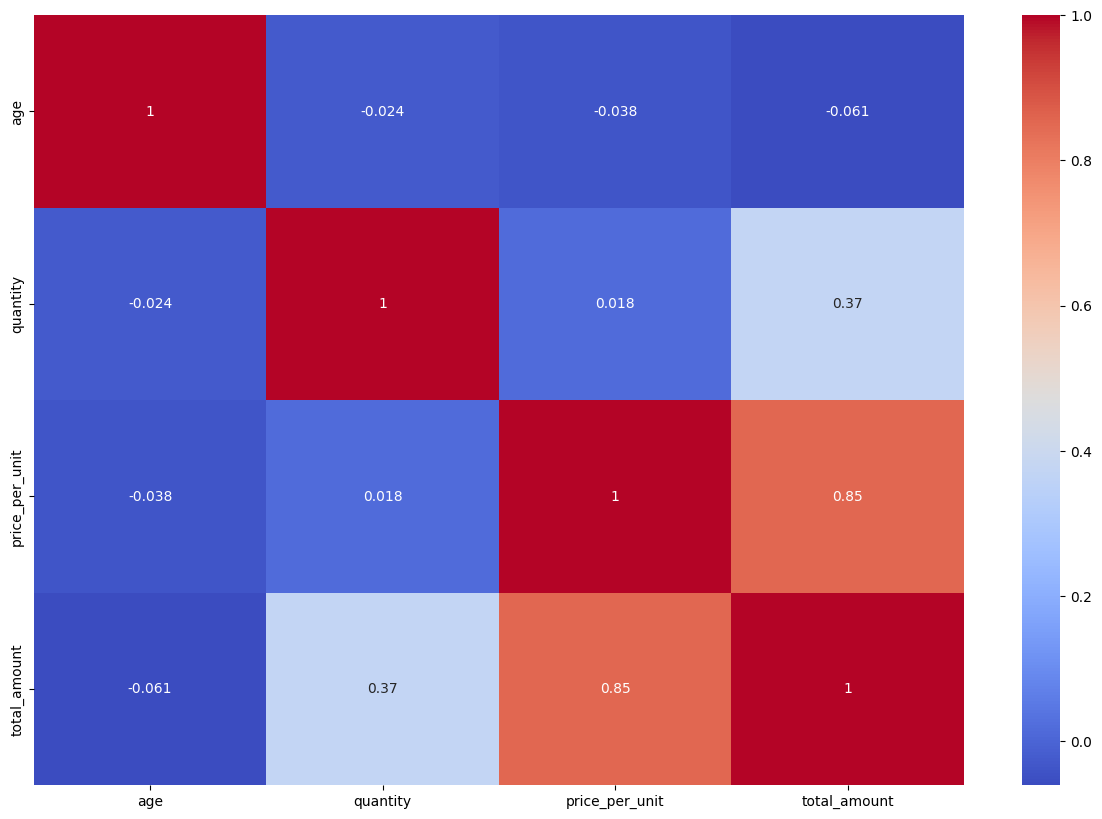

In [8]:
# Mapa de correlación

columns_corr = ['age','quantity', 'price_per_unit', 'total_amount']

plt.figure(figsize=(15,10))
sns.heatmap(df[columns_corr].corr(), annot=True, cmap='coolwarm')
plt.show()


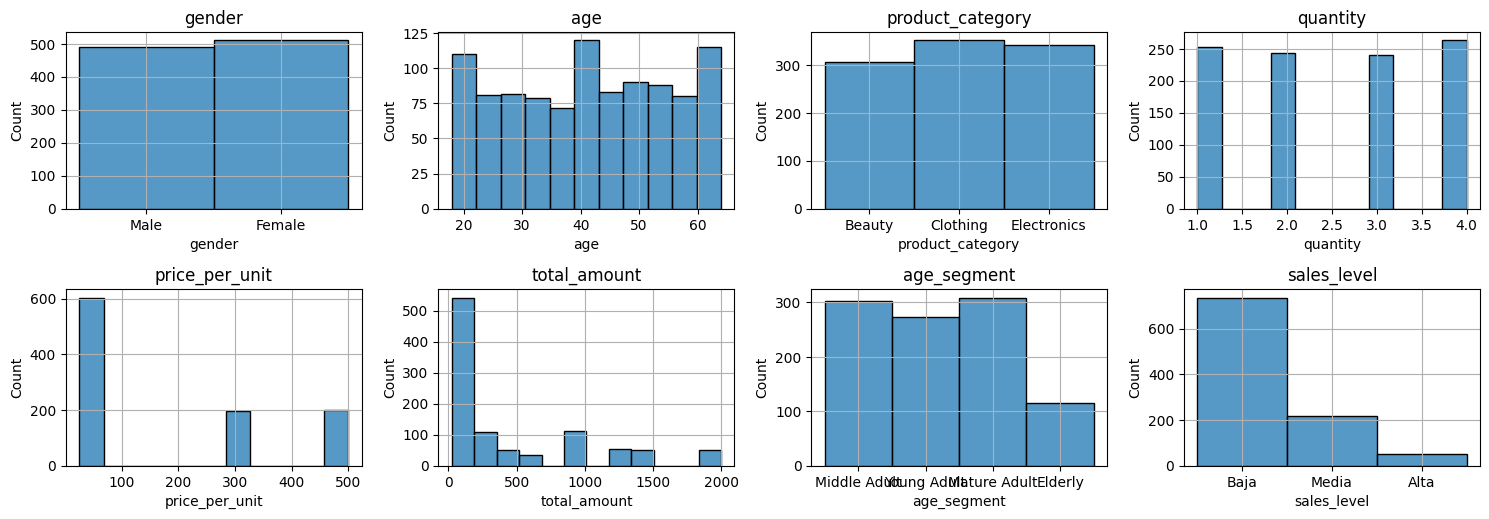

In [9]:
# Histograma de distribucion de las variables
plt.figure(figsize=(15,10))

columns = ['gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount',
       'age_segment', 'sales_level']

for i, col in enumerate(columns):
  plt.subplot(4, 4, i + 1)
  sns.histplot(df[col])
  plt.title(col)
  plt.grid(True)

plt.tight_layout()

plt.show()

La mayoría de las variables se encuentra distribuida de forma similar, a excepción de las variables monetarias como price per unit, total amount y sales level que presentan una inclinación hacia la izquiera (valores más bajos son mas frecuentes)

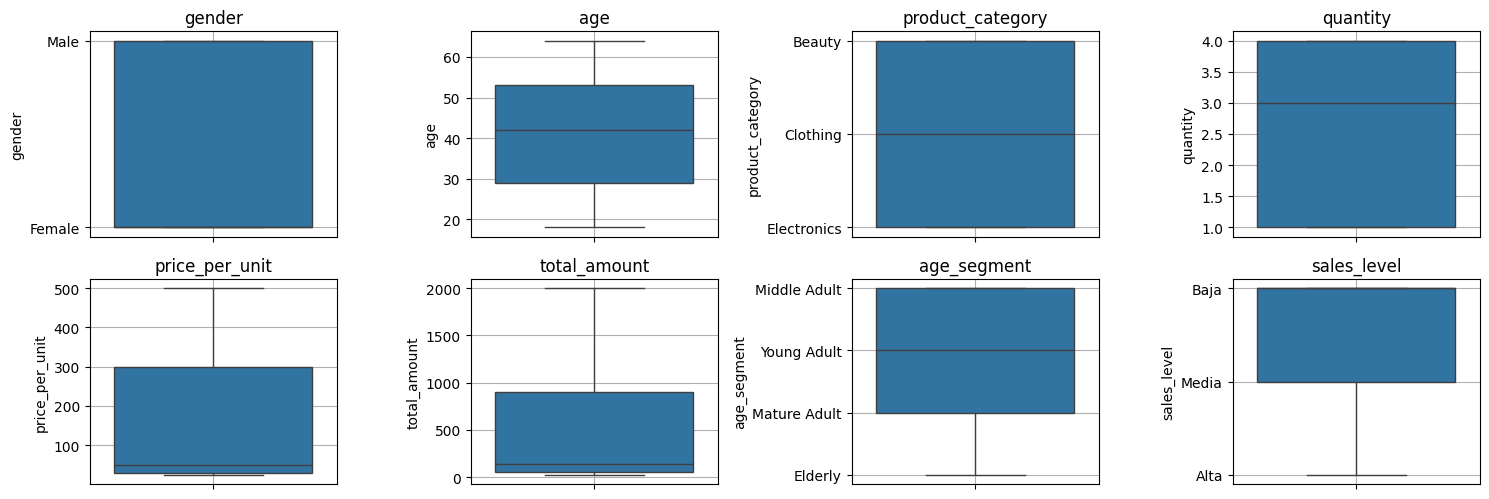

In [10]:
#boxplot para identificar outliers
plt.figure(figsize=(15,10))

columns = ['gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount',
       'age_segment', 'sales_level']

for i, col in enumerate(columns):
  plt.subplot(4, 4, i + 1)
  sns.boxplot(df[col])
  plt.title(col)
  plt.grid(True)
plt.tight_layout()
plt.show()

Si bien existen valores que se alejan de la media en algunas variables, no existen valores lo suficientemente apartados para ser considerados outliers.

# Parte 2: Preprocesamiento de Datos

In [11]:
df.columns

Index(['unnamed:_0', 'transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount',
       'age_segment', 'sales_level'],
      dtype='object')

In [12]:
# Dividir features.
X = df.drop(columns=['unnamed:_0', 'transaction_id', 'customer_id', 'total_amount'])
y = df['total_amount']

In [13]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Separar variables.
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
ord_cols = ['sales_level']
nom_cols = ['gender', 'product_category', 'age_segment']

In [15]:
# Escalar y codificar
num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

ord_pipeline = Pipeline(steps=[
    ("encoder", OrdinalEncoder()),
    ("scaler", StandardScaler())
])

nom_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Parte 3: Benchmarking de Técnicas de Machine Learning

### Árbol de decisión

In [18]:
# Preprocesamiento.
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("ord", ord_pipeline, ord_cols),
    ("nom", nom_pipeline, nom_cols)
])

In [54]:
# Pipeline final con árbol de decisión.

pipeline_tree = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeRegressor(random_state=42))
])

In [56]:
# Validación cruzada con 5 folds
scores = cross_val_score(pipeline_tree, X, y, cv=5, scoring='r2')

# Resultados
print("R²:", scores.mean())

R²: 1.0


In [57]:
# Entrenar.
pipeline_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'quantity',
                                                   'price_per_unit']),
                                                 ('ord',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sales_level']),
                                                 ('nom',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'product_category',
                                                   'age_segment'])])),
                ('classifier', DecisionTreeRegressor(random_state=42))])

In [58]:
# Evaluar.
y_pred = pipeline_tree.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2}")

R²: 1.0


### Regresión Lineal

In [25]:
# Preprocesamiento.
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("ord", ord_pipeline, ord_cols),
    ("nom", nom_pipeline, nom_cols)
])

In [26]:
# Pipeline
pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

In [37]:
# Validación cruzada
r2_scores = cross_val_score(pipeline_lr, X, y, cv=5, scoring='r2')

# Resultados
print("R² promedio:", r2_scores.mean())

R² promedio: 0.8444645725629767


In [38]:
# Entrenamiento
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'quantity',
                                                   'price_per_unit']),
                                                 ('ord',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sales_level']),
                                                 ('nom',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'product_category',
                                                   'age_segment'])])),
                ('regressor', LinearRegression())])

In [39]:
# Prediccion
y_pred_lr = pipeline_lr.predict(X_test)

In [40]:
# Métricas de evaluacion
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print(f"  MSE: {mse_lr}")
print(f"  RMSE: {rmse_lr}")
print(f"  R²: {r2_lr}")

Linear Regression:
  MSE: 43464.97915658471
  RMSE: 208.4825631955457
  R²: 0.8515181231916455


#KNN Regressor

In [43]:
# Preprocesamiento.
preprocessor_knn = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("ord", ord_pipeline, ord_cols),
    ("nom", nom_pipeline, nom_cols)
])

In [46]:
# Modelo pipeline
pipeline_knn = Pipeline([
    ("preprocessing", preprocessor_knn),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

In [48]:
r2_scores = cross_val_score(pipeline_knn, X, y, cv=5, scoring='r2')
print("R² por fold:", r2_scores)
print("R² promedio:", r2_scores.mean())

R² por fold: [0.9518836  0.93831442 0.9576602  0.96303321 0.95503828]
R² promedio: 0.953185941055338


In [49]:
# Entrenamiento.
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'quantity',
                                                   'price_per_unit']),
                                                 ('ord',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sales_level']),
                                                 ('nom',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'product_category',
                                                   'age_segment'])])),
                ('model', KNeighborsRegressor())])

In [50]:
# Prediccion.
y_pred_knn = pipeline_knn.predict(X_test)

In [51]:
# Métricas de evaluacion
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("Linear Regression:")
print(f"  MSE: {mse_knn}")
print(f"  RMSE: {rmse_knn}")
print(f"  R²: {r2_knn}")

Linear Regression:
  MSE: 15737.7
  RMSE: 125.44999003587047
  R²: 0.9462380224725626


Los resulrados obtenidos con validación cruzada son:
* KNN Regressor: R² promedio: 0.95
* Linear Regression: R²: 0.85
* Decision Tree Regresor: R²: 1.0


La mejor opción en este caso sería el modelo con árbol de decisión ya que da un R²: de 1.0. Sin embargo, este resultado podria ser poco realista debido a que el dataset puede tener muy pocos datos y eso puede ocasionar un overfitting, por lo tanto, el modelo KNN ofrece un porcentaje quizas menor pero mas realista, y aun sigue siendo un buen resultado 95%